#### What we're doing

This is a HTET script for a 0+1D scalar field theory (quantum mechanics)

We use:

$$H = \frac{1}{2}\Pi^2 + \frac{1}{2}\phi^2 + \lambda \phi^4 $$

Free part is just harmonic oscillator and $\lambda$ term is the interaction term

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#### Annihilation and Creation Operators

```N``` is the number of truncated states

standard ladder operators for fock basis {$\ket{0}, \ket{1}, \ket{2},...\ket{N-1},$}

$ a\ket{n} = \sqrt{n}\ket{n-1} ~~~~ a^{\dagger} \ket{n} = \sqrt{n+1}\ket{n+1} $ 

In [2]:
def ladder_ops(N: int):
    a = np.zeros((N, N), dtype=float)
    adag = np.zeros((N,N), dtype=float)
    for n in range(1, N):
        a[n - 1, n] = np.sqrt(n)
    for n in range(0, N-1):
        adag[n+1, n] = np.sqrt(n+1)
    return a, adag


In [3]:
ladder_operators = ladder_ops(5)

print("a:")
print(ladder_operators[0])
print("~" * 20)
print("adag:")
print(ladder_operators[1])

a:
[[0.         1.         0.         0.         0.        ]
 [0.         0.         1.41421356 0.         0.        ]
 [0.         0.         0.         1.73205081 0.        ]
 [0.         0.         0.         0.         2.        ]
 [0.         0.         0.         0.         0.        ]]
~~~~~~~~~~~~~~~~~~~~
adag:
[[0.         0.         0.         0.         0.        ]
 [1.         0.         0.         0.         0.        ]
 [0.         1.41421356 0.         0.         0.        ]
 [0.         0.         1.73205081 0.         0.        ]
 [0.         0.         0.         2.         0.        ]]


#### Construct $\phi$ and $\Pi$

```omega``` is the input frequency

$$\phi = \frac{a+a^{\dagger}}{\sqrt{2\omega}}$$

$$\Pi = \sqrt{\frac{\omega}{2}} (a^{\dagger}-a) $$

In [4]:
def ho_operators(N: int, omega: float):
    a, adag = ladder_ops(N)
    phi = (a + adag) / np.sqrt(2.0 * omega)
    pi = 1j * np.sqrt(omega / 2.0) * (adag - a)
    return phi, pi, a, adag


In [5]:
phi, pi, a, adag = ho_operators(6, 1)

print("phi:")
print(phi)
print("~" * 20)
print("phi^2:")
print(2* phi @ phi)
print("~" * 20)
print("phi^4:")
print(4 * phi @ phi @ phi @ phi)

phi:
[[0.         0.70710678 0.         0.         0.         0.        ]
 [0.70710678 0.         1.         0.         0.         0.        ]
 [0.         1.         0.         1.22474487 0.         0.        ]
 [0.         0.         1.22474487 0.         1.41421356 0.        ]
 [0.         0.         0.         1.41421356 0.         1.58113883]
 [0.         0.         0.         0.         1.58113883 0.        ]]
~~~~~~~~~~~~~~~~~~~~
phi^2:
[[1.         0.         1.41421356 0.         0.         0.        ]
 [0.         3.         0.         2.44948974 0.         0.        ]
 [1.41421356 0.         5.         0.         3.46410162 0.        ]
 [0.         2.44948974 0.         7.         0.         4.47213595]
 [0.         0.         3.46410162 0.         9.         0.        ]
 [0.         0.         0.         4.47213595 0.         5.        ]]
~~~~~~~~~~~~~~~~~~~~
phi^4:
[[ 3.          0.          8.48528137  0.          4.89897949  0.        ]
 [ 0.         15.          0.     

#### Full Hamiltonian

This is the free and interacting parts of the hamiltonian in the HO basis

In [6]:
def build_H0(N: int, omega: float):
    phi, pi, _, _ = ho_operators(N, omega)
    return 0.5 * (pi @ pi) + 0.5 * omega**2 * (phi @ phi)

def build_V(N: int, omega: float, lam: float):
    phi, _, _, _ = ho_operators(N, omega)
    phi2 = phi @ phi
    phi4 = phi2 @ phi2
    V_mass = 0.5 * (1.0 - omega**2) * phi2
    V_x4   = (lam / 24.0) * phi4
    return V_mass + V_x4

def build_full_H(N: int, omega: float, lam: float):
    return build_H0(N, omega) + build_V(N, omega, lam)


##### Defines the UV cutoff on the Hamiltonian

- Assumes HO free Hamiltonian
- Uses known analytic spectrum
- splits basis into low energy and high energy sectors P and Q respectively

inputs:
```omega``` is the input frequency 

```Emax``` is the UV cutoff

```N_uv``` is the regulator of the space size not the HTET cutoff

In [7]:
def indices_below_Emax(omega: float, Emax: float, N_uv: int):
    n = np.arange(N_uv)
    En = omega * (n + 0.5)
    P = np.where(En <= Emax)[0]
    Q = np.where(En > Emax)[0]
    return P, Q, En

#### Building the effective Hamiltonian

The Hamiltonian constructed here acts only within the low energy space P but includes effects of the excluded high energy space Q through the HTET matching correction at $O(V^2)$:

$$H_{eff}=P(H_0+V)P + H_2 ~~~~~ (H_2)_{fi} = \sum_{\alpha \in Q} \frac{V_{f\alpha}V_{\alpha i}}{E_f - E_\alpha}$$

THe function returns (Heff, P, Q) where Heff is the P space effective Hamiltonian matched through O(V^2) using Cohen 2.23b.

Also in general this is non hermitian which is expected from Cohen

##### Second Order H:

In [8]:
def naive_Heff(N_uv: int, omega: float, lam: float, Emax: float):
    #build H0 and V in the truncated basis
    #gives the "fundamental data" needed for matching
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    #checking we actually have P states to use
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    # Project to blocks
    # our original is built from H0_PP and V_PP
    # our correction is built from V_PQ and V_QP
    H0_PP = H0[np.ix_(P, P)] #P H0 P
    V_PP = V[np.ix_(P, P)] #P V P
    V_PQ = V[np.ix_(P, Q)] #P V Q
    V_QP = V[np.ix_(Q, P)] # Q V P

    # We build the "naive truncation" (PHP)
    Heff = H0_PP + V_PP

    Heff = 0.5 *(Heff + Heff.conj().T)

    return Heff, P, Q, H0, V

In [9]:
def htet_Heff_O_V2(N_uv: int, omega: float, lam: float, Emax: float):
    
    #build H0 and V in the truncated basis
    #gives the "fundamental data" needed for matching
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    #checking we actually have P states to use
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    # Project to blocks
    # our original is built from H0_PP and V_PP
    # our correction is built from V_PQ and V_QP
    H0_PP = H0[np.ix_(P, P)] #P H0 P
    V_PP = V[np.ix_(P, P)] #P V P
    V_PQ = V[np.ix_(P, Q)] #P V Q
    V_QP = V[np.ix_(Q, P)] # Q V P

    # We build the "naive truncation" (PHP)
    Heff = H0_PP + V_PP

    # set up construction of H2
    H2 = np.zeros((nP, nP), dtype=complex)

    #pull out the H0 energies for P and Q (for denominators)
    EP = En[P]  # energies for P states (H0) -  EP[f] is the free energy of the P state |f>
    EQ = En[Q]  # energies for Q states (H0) - EP[a] is the freee energy of the Q state |a>

    # Compute correction row by row
    for f in range(nP):
        Ef = EP[f] # fix final p state |f>
        inv = 1.0 / (Ef - EQ) # build denominators
        H2[f, :] = (V_PQ[f, :] * inv) @ V_QP # construct correction

    H2 = 0.5 * (H2 + H2.conj().T)
    Heff = Heff + H2
    return Heff, P, Q, H0, V # theres the full effective hamiltonian :)

##### Third order H

We can include higher order H by doing 

$$H_{eff}= P(H_0+V)P + H_2 + H_3$$

where 

$$ (H_3)_{fi} = \sum_{\alpha,\beta \in Q} \frac{V_{f \alpha} V_{\alpha \beta} V_{\beta i}}{(E_f - E_\alpha)(E_f-E_\beta)} - \sum_{\alpha \in P} \sum_{\beta \in Q}\frac{V_{f \alpha} V_{\alpha \beta} V_{\beta i}}{(E_\alpha - E_\beta)(E_f-E_\beta)} $$


Should make a note here to say this actually heavily uses projectors as in the actual form Im using isnt the above it's more similar to:

$$ H_3(E_f) = PVQ \frac{1}{E_f - H_0} QVQ \frac{1}{E_f - H_0} QVP - PVP \frac{1}{E_P - H_0} PVQ \frac{1}{E_f - H_0} QVP $$


where we construct P and Q implicity by constructing block matrices of V, $H_0$ is the solvable free energy,explicitly:  PVQ starts in thehigh energy space, acts with V and projects into the low energy space, QVP is the inverse of this, QVQ is the interaction restricted to the high energy subspace and similarly PVP is the retained low energy space, $\frac{1}{E_f - H_0}$ is equivalent to the denominators $\frac{1}{E_f-E_\alpha}$ and similarly $\frac{1}{E_P - H_0} \to \frac{1}{E_\alpha - E_\beta}$ 

In [10]:
def htet_Heff_O_V3(N_uv: int, omega: float, lam: float, Emax: float):
    Heff, P, Q, H0, V = htet_Heff_O_V2(N_uv, omega, lam, Emax)

    _, _, En = indices_below_Emax(omega, Emax, N_uv)

    nP = len(P)
    nQ = len(Q)
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")
    if nQ == 0:
        # No high energy states mean no matching correction
        return Heff, P, Q, H0, V

    # Blocks of V
    V_PP = V[np.ix_(P, P)]  # (nP, nP) 
    V_PQ = V[np.ix_(P, Q)]  # (nP, nQ) 
    V_QP = V[np.ix_(Q, P)]  # (nQ, nP) 
    V_QQ = V[np.ix_(Q, Q)]  # (nQ, nQ)

    H3 = np.zeros((nP, nP), dtype=complex)

    EP = En[P]   # shape (nP,)
    EQ = En[Q]   # shape (nQ,)

    denom_PQ = EP[:, None] - EQ[None, :] # shape (nP, nQ)
    A = V_PQ / denom_PQ # useful easy prefactor

    for f in range(nP):
        Ef = EP[f]
        inv_f = 1.0 / (Ef - EQ) # new factor

        #first term
        tmp_b = (V_PQ[f, :] * inv_f) @ V_QQ  # shape (nQ,)
        # multiply by 1/(Ef-Eb) and sum into i via V_bi
        term1_row = (tmp_b * inv_f) @ V_QP   # shape (nP,)

        #second term (we use the A we made previously)
        s_b = V_PP[f, :] @ A                 # shape (nQ,)
        term2_row = (s_b * inv_f) @ V_QP     # shape (nP,)

        H3[f, :] = term1_row - term2_row

    H3 = 0.5 * (H3 + H3.conj().T)
    Heff3 = Heff + H3 # final effective hamiltonian
    return Heff3, P, Q, H0, V

#### GS energy

Computes eigenvalues of of H then gives the minimum 

def ground_state_energy_from_matrix(H):
    evals, vecs = np.linalg.eig(H) # extracts jth eigenvalue and coresponding eigenvector
    weights = np.abs(vecs[0, :])**2 # extracts overlap of each eigenvector with HO ground state
    j = np.argmax(weights) # finds index of eigenvector with largest overlap
    return evals[j], evals # returns eigenvalue associated with the physically relevant ground state and all eigenvalues

#we do this complicated thing because if we dont we end up with majorly negative energies


In [11]:
def ground_state_energy_from_matrix(H):
    evals = np.linalg.eigvalsh(H)  # Hermitian
    return evals[0], evals

def ground_state_energy_from_matrix(H):
    evals = np.linalg.eig(H)[0]
    #print(f"GS: {np.min(abs(evals))}")
    return np.min(abs(evals)), 1


##### Run of functions and raw comparison

In [12]:
# default run
def run_energy_scan(heff: str, omega=1.0,lam=1.0,N_uv=200,Emax_list=(6.0, 7.0, 8.0, 9.0, 10.0), Known_E = 1.0, print_table=True): 
    results = np.zeros((len(Emax_list), 5), dtype=float)
    
    H_full = build_full_H(N_uv, omega, lam) #builds the Hamiltonian in truncated basis

    #prints info and table headers
    if print_table:
        print(f"omega={omega}  lambda(Cohen)={lam}  N_uv={N_uv}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    #loops over each Emax
    for Emax in Emax_list:
        #defines P,Q,En for given Emax
        P, Q, En = indices_below_Emax(omega, Emax, N_uv)
        nP = len(P)

        # sets up a raw truncation to benchmark
        H_raw = H_full[np.ix_(P, P)]
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        # HTET through O(V^2)
        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet)

        percentage_error = abs((Known_E - E0_htet) / Known_E)

        results[Emax_list.index(Emax), :] = [Emax, nP, E0_raw, E0_htet, percentage_error]

        if print_table:
            print(f"{Emax:4.1f} | {nP:6d} | "f"{E0_raw.real: .10f},{E0_raw.imag: .2e} | "f"{E0_htet.real: .10f},{E0_htet.imag: .2e} | {percentage_error: .2e}")

    return results

In [13]:
# default run
def run_omega_scan(heff: str, omega_list=(1.0,2.0,3.0,4.0,5.0),lam=1.0,N_uv=200,Emax=50.0, Known_E = 1.0, print_table=True): 
    results = np.zeros((len(omega_list), 6), dtype=float)
    
        #prints info and table headers
    if print_table:
        print(f"omega={omega_list[0]}  lambda(Cohen)={lam}  N_uv={N_uv}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    #loops over each Emax
    for omega in omega_list:
        H_full = build_full_H(N_uv, omega, lam) #builds the Hamiltonian in truncated basis
        #defines P,Q,En for given Emax
        P, Q, En = indices_below_Emax(omega, Emax, N_uv)
        nP = len(P)

        # sets up a raw truncation to benchmark
        H_raw = H_full[np.ix_(P, P)]
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        # HTET through O(V^2)
        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet)

        percentage_error = abs((Known_E - E0_htet) / Known_E)

        results[omega_list.index(omega), :] = [Emax, nP, E0_raw, E0_htet, percentage_error, omega]

        if print_table:
            print(f"{Emax:4.1f} | {nP:6d} | "f"{E0_raw.real: .10f},{E0_raw.imag: .2e} | "f"{E0_htet.real: .10f},{E0_htet.imag: .2e} | {percentage_error: .2e}")

    return results

In [14]:
# default run
def run_uv_scan(heff: str, omega=1.0,lam=1.0,N_uv=(2**2,2**3,2**4),Emax=50.0, Known_E = 1.0, print_table=True): 
    results = np.zeros((len(N_uv), 7), dtype=float)
    
    #prints info and table headers
    if print_table:
        print(f"omega={omega}  lambda(Cohen)={lam}  N_uv={N_uv}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    #loops over each Emax
    for uv in N_uv:
        H_full = build_full_H(uv, omega, lam) #builds the Hamiltonian in truncated basis
        #defines P,Q,En for given Emax
        P, Q, En = indices_below_Emax(omega, Emax, uv)
        nP = len(P)

        # sets up a raw truncation to benchmark
        H_raw = H_full[np.ix_(P, P)]
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        # HTET through O(V^2)
        H_htet, _, _, _, _ = Heff_dict[heff](uv, omega, lam, Emax)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet)

        percentage_error = abs((Known_E - E0_htet) / Known_E)

        results[N_uv.index(uv), :] = [Emax, nP, E0_raw, E0_htet, percentage_error, omega, uv]

        if print_table:
            print(f"{Emax:4.1f} | {nP:6d} | "f"{E0_raw.real: .10f},{E0_raw.imag: .2e} | "f"{E0_htet.real: .10f},{E0_htet.imag: .2e} | {percentage_error: .2e}")

    return results

In [15]:
E0 = 0.52773612731410831269035109114701621561393954399308 #E0 for lambda = 1 0+1D
Emax_List = list(np.linspace(0.6, 20, 500))
omega_list = list(np.linspace(0.5,5,500))
nQ_list = (2,3,4,5,6,7,8,9)
N_uv_list = []
for nQ in nQ_list:
    ns = int(2**nQ)
    N_uv_list.append(ns)


best error for H3 is 2.797456892915344e-11 at 16.0
best error for H2 is 2.797456892915344e-11 at 16.0
best error for H1 is 7.764928288588482e-13 at 32.0


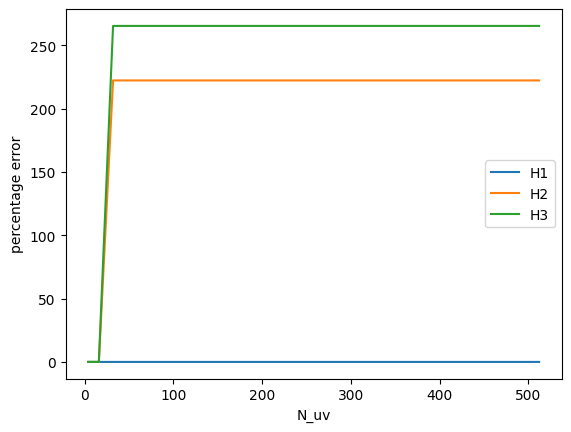

In [16]:
uv_results_H1 =run_uv_scan(
    heff="H1",
    omega=1,
    lam=1.0,
    N_uv=N_uv_list,
    Emax=20, 
    Known_E=E0,
    print_table=False
    )

uv_results_H2 =run_uv_scan(
    heff="H2",
    omega=1,
    lam=1.0,
    N_uv=N_uv_list,
    Emax=20, 
    Known_E=E0,
    print_table=False
    )

uv_results_H3 =run_uv_scan(
    heff="H3",
    omega=1,
    lam=1.0,
    N_uv=N_uv_list,
    Emax=20, 
    Known_E=E0,
    print_table=False
    )

print(f"best error for H3 is {min(uv_results_H3[:, 4])} at {uv_results_H3[np.argmin(uv_results_H3[:, 4]), 6]}")
print(f"best error for H2 is {min(uv_results_H2[:, 4])} at {uv_results_H2[np.argmin(uv_results_H2[:, 4]), 6]}")
print(f"best error for H1 is {min(uv_results_H1[:, 4])} at {uv_results_H1[np.argmin(uv_results_H1[:, 4]), 6]}")


plt.plot(uv_results_H1[:, 6], uv_results_H1[:, 4], label = "H1")
plt.plot(uv_results_H2[:, 6], uv_results_H2[:, 4], label = "H2")
plt.plot(uv_results_H3[:, 6], uv_results_H3[:, 4], label = "H3")
plt.legend()
plt.xlabel("N_uv")
plt.ylabel("percentage error")
plt.show()


best error for H3 is 2.8248960583632063e-09
best error for H2 is 2.8248960583632063e-09
best error for H2 is 2.8248960583632063e-09


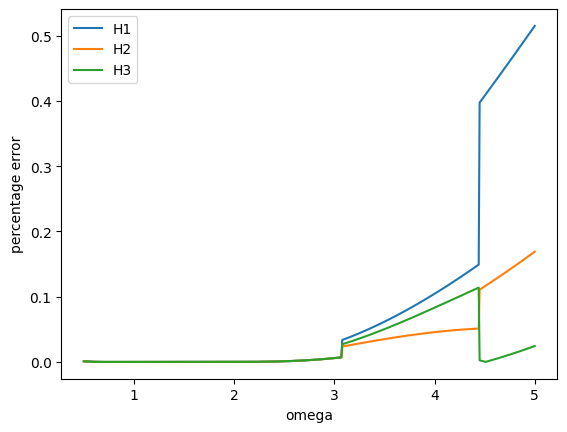

In [17]:
O_results_H1 =run_omega_scan(
    heff="H1",
    omega_list=omega_list,
    lam=1.0,
    N_uv=2**3,
    Emax=20, 
    Known_E=E0,
    print_table=False
    )

O_results_H2 =run_omega_scan(
    heff="H2",
    omega_list=omega_list,
    lam=1.0,
    N_uv=2**3,
    Emax=20, 
    Known_E=E0,
    print_table=False
    )

O_results_H3 =run_omega_scan(
    heff="H3",
    omega_list=omega_list,
    lam=1.0,
    N_uv=2**3,
    Emax=20, 
    Known_E=E0,
    print_table=False
    )

print(f"best error for H3 is {min(O_results_H3[:, 4])}")
print(f"best error for H2 is {min(O_results_H2[:, 4])}")
print(f"best error for H2 is {min(O_results_H1[:, 4])}")

plt.plot(O_results_H1[:, 5], O_results_H1[:, 4], label = "H1")
plt.plot(O_results_H2[:, 5], O_results_H2[:, 4], label = "H2")
plt.plot(O_results_H3[:, 5], O_results_H3[:, 4], label = "H3")
plt.xlabel("omega")
plt.ylabel("percentage error")
plt.legend()
plt.show()

this is bad kind of:

I need to fix the dimension of P as currently its scaling with w for this graph (thats why it looks unstable)

other than that though as we keep emax constant as E=w(n+1/2) is constantly increasing fewer and fewer states satisfy E < Emax so thats why we see some sharp vertical jumps

as for the decrease for H3 im pretty surethis is because Q (the higher energy stuff) is becoming empty as so the correction is vanishing whereas H1 doesnt have that feature, id anticpate something similar for H2 as well 

generally the curves grow for fixed emax as increasing omega makes free spacing larger, interacting gs becomes less well captured by small P and so truncation error grows, ergo the order H3 < H2 < H1 (althought there is that really strange middle bit between ~3 and ~4.5)

best error for H3 is 2.787614304594837e-09 at 12.418837675350701
best error for H2 is 2.787614304594837e-09 at 12.418837675350701
best error for H1 is 2.787614304594837e-09 at 11.602404809619237


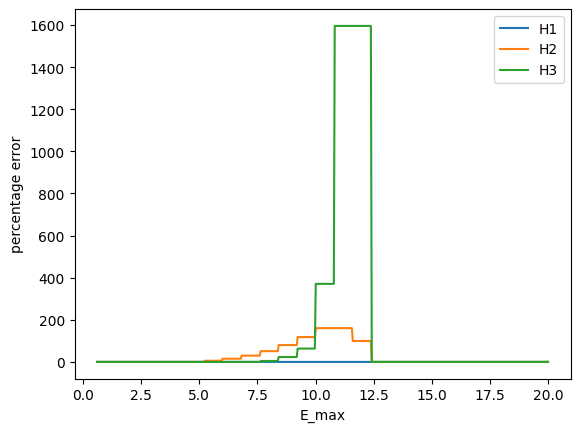

In [18]:
E_results_H1 =run_energy_scan(
    heff="H1",
    omega=0.8,
    lam=1.0,
    N_uv=16,
    Emax_list=Emax_List, 
    Known_E=E0,
    print_table=False
    )

E_results_H2 =run_energy_scan(
    heff="H2",
    omega=0.8,
    lam=1.0,
    N_uv=16,
    Emax_list=Emax_List, 
    Known_E=E0,
    print_table=False
    )

E_results_H3 =run_energy_scan(
    heff="H3",
    omega=0.8,
    lam=1.0,
    N_uv=16,
    Emax_list=Emax_List, 
    Known_E=E0,
    print_table=False
    )

print(f"best error for H3 is {min(E_results_H3[:, 4])} at {E_results_H3[np.argmin(E_results_H3[:, 4]), 0]}")
print(f"best error for H2 is {min(E_results_H2[:, 4])} at {E_results_H2[np.argmin(E_results_H2[:, 4]), 0]}")
print(f"best error for H1 is {min(E_results_H1[:, 4])} at {E_results_H1[np.argmin(E_results_H1[:, 4]), 0]}")

plt.plot(E_results_H1[:, 0], E_results_H1[:, 4], label = "H1")
plt.plot(E_results_H2[:, 0], E_results_H2[:, 4], label = "H2")
plt.plot(E_results_H3[:, 0], E_results_H3[:, 4], label = "H3")


plt.xlabel("E_max")
plt.ylabel("percentage error")
plt.legend()
plt.show()

bigger spike is expected as for each we have denominators E-H, H1 has no denominator, so no spike, H2 has 1 denominator, H3 has squared denominator so bigger spike

discrete steps are caused by the fact that the P states only change when Emax crosses a discrete energy (easier to think about this in terms of energy states free spectrum is discrete (E = w(n+1/2) so p space only changes at one of these bondaries)

In [19]:
# default run
def run_Emax_uv_scan(heff: str, omega=1.0,lam=1.0,N_uv=(2**2,2**3,2**4),Emax_list=(6.0, 7.0, 8.0, 9.0, 10.0), Known_E = 1.0, print_table=True): 
    results = np.zeros((len(N_uv)*len(Emax_list), 3), dtype=float)

    #prints info and table headers
    if print_table:
        print(f"omega={omega}  lambda(Cohen)={lam}  N_uv={N_uv}")
        print("Emax | N_uv | percentage error (rel to known)")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    i = 0
    #loops over each Emax
    for uv in N_uv:
        for Emax in Emax_list:
            H_full = build_full_H(uv, omega, lam) #builds the Hamiltonian in truncated basis
            #defines P,Q,En for given Emax
            P, Q, En = indices_below_Emax(omega, Emax, uv)
            nP = len(P)

            # sets up a raw truncation to benchmark
            H_raw = H_full[np.ix_(P, P)]
            E0_raw, _ = ground_state_energy_from_matrix(H_raw)

            # HTET through O(V^2)
            H_htet, _, _, _, _ = Heff_dict[heff](uv, omega, lam, Emax)
            E0_htet, _ = ground_state_energy_from_matrix(H_htet)

            percentage_error = abs((Known_E - E0_htet) / Known_E)

            results[i] = [Emax, uv, percentage_error]

            i +=1

            if print_table:
                print(f"{Emax:4.1f}| {uv:4d} | {percentage_error: .2e}")

    return results

H1: min rel error = 6.311e-16 at Emax = 20.061, N_uv = 26


C:\Users\alexm\AppData\Local\Temp\ipykernel_19704\589135363.py:50: UserWarning: Attempt to set non-positive zlim on a log-scaled axis will be ignored.
  ax.set_zscale("log")


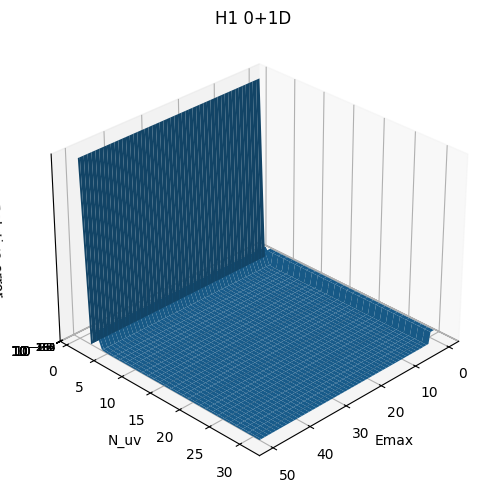

H2: min rel error = 6.311e-16 at Emax = 20.560, N_uv = 26


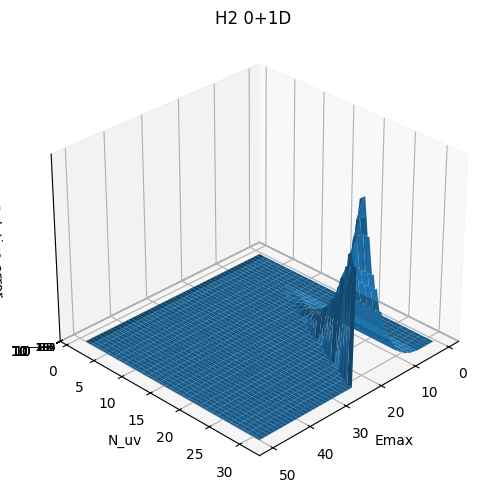

H3: min rel error = 6.311e-16 at Emax = 20.560, N_uv = 26


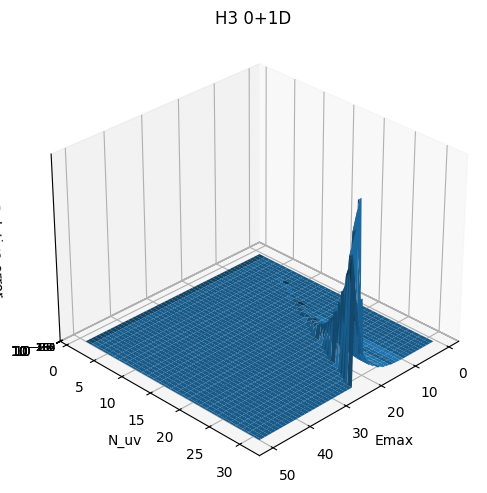

In [20]:
Emax2 = list(np.linspace(0.6, 50, 100))
nQ_list = (2,3,4,5)
N_uv2 = []
for nQ in nQ_list:
    ns = int(2**nQ)
    N_uv2.append(ns)

N_uv2 = np.arange(1,32)

for H in ["H1", "H2", "H3"]:
    E_uv_results_H1 =run_Emax_uv_scan(
        heff=H,
        omega=0.8,
        lam=1.0,
        N_uv=N_uv2,
        Emax_list=Emax2, 
        Known_E=E0,
        print_table=False
        )

    res = E_uv_results_H1

    # min error location
    imin = np.argmin(res[:, 2])
    Emax_min = res[imin, 0]
    Nuv_min  = int(res[imin, 1])
    err_min  = res[imin, 2]

    print(f"{H}: min rel error = {err_min:.3e} at Emax = {Emax_min:.3f}, N_uv = {Nuv_min}")

    Emax_vals = np.unique(res[:, 0])
    Nuv_vals  = np.unique(res[:, 1])

    # Make sure points are in consistent order for reshaping:
    order = np.lexsort((res[:, 0], res[:, 1]))   # sort by N_uv then Emax
    res_sorted = res[order]

    Z = res_sorted[:, 2].reshape(len(Nuv_vals), len(Emax_vals))  # rows=N_uv, cols=Emax
    X, Y = np.meshgrid(Emax_vals, Nuv_vals)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)

    ax.set_title(f"{H} 0+1D")
    ax.set_xlabel("Emax")
    ax.set_ylabel("N_uv")
    ax.set_zlabel("Relative error")
    ax.set_zscale("log")

    plt.tight_layout()

    ax.view_init(elev=30, azim=45)

    plt.show()


